# 02 - Unsupervised Regimes

Goal: group similar market days without using trading labels.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

from nvda_rl.features import FEATURE_COLUMNS, describe_regimes, fit_unsupervised_features

sns.set_theme(style="whitegrid", context="notebook")
data = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "nvda_features.csv", parse_dates=["date"])

## How k-means works

K-means tries to place days into groups where days inside one group look similar.

It starts with cluster centers, assigns each day to the closest center, then moves centers and repeats.

We scale features first because RSI, returns, and volume z-score use different units.

In [3]:
enriched, regime_model, pca_model = fit_unsupervised_features(data, n_clusters=3)
scaled_features = regime_model.named_steps["scaler"].transform(enriched[FEATURE_COLUMNS])
score = silhouette_score(scaled_features, enriched["regime"])
print(f"Silhouette score: {score:.3f}")

regime_summary = describe_regimes(enriched)
regime_summary

Silhouette score: 0.237


,days,avg_return,avg_volatility,avg_momentum_20d,avg_drawdown,avg_rsi,avg_atr_pct
regime,,,,,,,
2,968,-0.009383,0.034417,-0.097755,-0.340447,37.147390,0.052944
0,2462,0.003283,0.021267,0.046431,-0.195070,57.361321,0.030414
1,628,0.014151,0.032565,0.220905,-0.068061,73.769361,0.037340


Regime 2 is the stress regime: average return is around -0.94% per day, with weak momentum and deep drawdowns.
Regime 0 is the normal positive regime, and Regime 1 is the strong momentum regime.

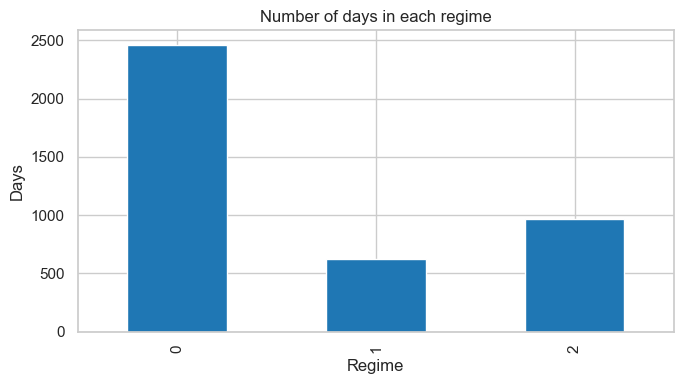

In [4]:
regime_counts = enriched["regime"].value_counts().sort_index()
regime_counts.plot(kind="bar", figsize=(7, 4), color="tab:blue")
plt.title("Number of days in each regime")
plt.xlabel("Regime")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

Regime 0 has the most days, so most trading days are normal positive days. Regime 1 is less frequent but has much stronger average return.

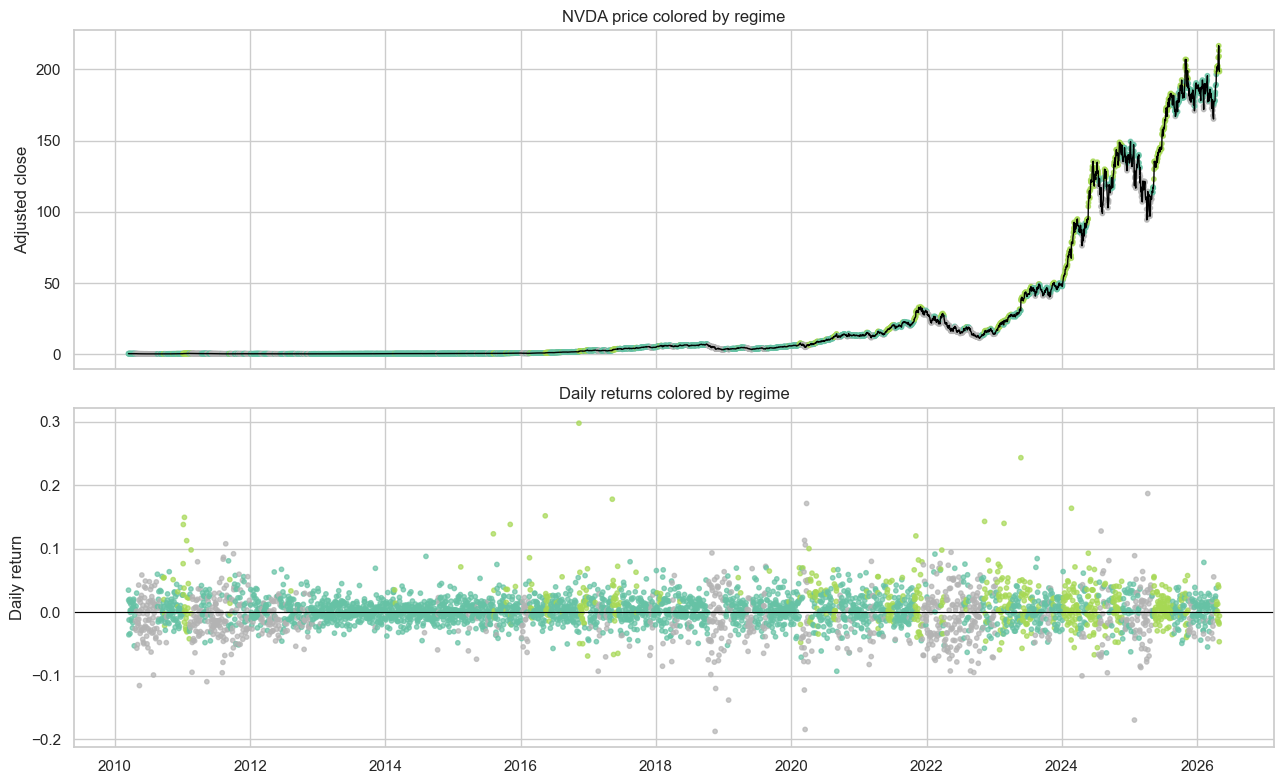

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(enriched["date"], enriched["adj_close"], color="black", linewidth=1)
axes[0].scatter(enriched["date"], enriched["adj_close"], c=enriched["regime"], cmap="Set2", s=10, alpha=0.8)
axes[0].set_title("NVDA price colored by regime")
axes[0].set_ylabel("Adjusted close")

axes[1].scatter(enriched["date"], enriched["return"], c=enriched["regime"], cmap="Set2", s=10, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Daily returns colored by regime")
axes[1].set_ylabel("Daily return")
plt.tight_layout()
plt.show()

The stress regime appears around large price disruptions and drawdowns. This is useful because the RL agent can treat those days differently.

## How PCA works

PCA rotates the feature space into new axes that keep as much variation as possible.

We use two PCA columns as compact market-state signals for RL.

PC1 explained variance: 41.01%
PC2 explained variance: 15.24%


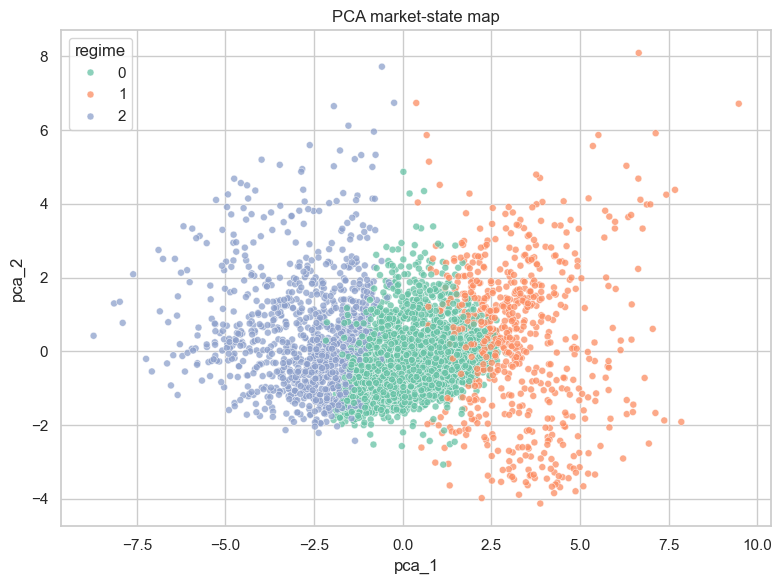

In [6]:
explained = pca_model.named_steps["pca"].explained_variance_ratio_
print(f"PC1 explained variance: {explained[0]:.2%}")
print(f"PC2 explained variance: {explained[1]:.2%}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=enriched, x="pca_1", y="pca_2", hue="regime", palette="Set2", s=25, alpha=0.75)
plt.title("PCA market-state map")
plt.tight_layout()
plt.show()

The PCA chart shows that regimes occupy different areas of the feature map, so the clusters are not just random labels.

In [7]:
transition = pd.crosstab(
    enriched["regime"].shift(1).rename("previous"),
    enriched["regime"].rename("current"),
    normalize="index",
)
transition

current,0,1,2
previous,,,
0.0,0.900081,0.038180,0.061738
1.0,0.146730,0.842105,0.011164
2.0,0.158058,0.006198,0.835744


The transition table shows whether regimes persist. Persistence matters because a regime that lasts more than one day is easier to trade.

In [8]:
output_path = PROJECT_ROOT / "data" / "processed" / "nvda_regimes.csv"
enriched.to_csv(output_path, index=False)
enriched[["date", "return", "volatility_20d", "rsi_14", "regime", "pca_1", "pca_2"]].head()

,date,return,volatility_20d,rsi_14,regime,pca_1,pca_2
0,2010-03-16,0.034965,0.024878,65.796404,0,0.681412,0.371679
1,2010-03-17,0.019144,0.025151,71.144280,0,1.058320,0.358320
2,2010-03-18,-0.035359,0.021594,64.125609,0,0.200107,-0.365138
3,2010-03-19,-0.012028,0.021773,54.975179,0,-0.114170,-0.389771
4,2010-03-22,0.016232,0.021996,58.041936,0,0.423017,0.000931


Output:

`nvda_regimes.csv` is the bridge from unsupervised learning to the RL notebooks.